In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('/content/sample_data/faults.csv')
display(df.head())

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X_Minimum,1941.0,5.711360e+02,5.206907e+02,0.0000,51.0000,4.350000e+02,1.053000e+03,1.705000e+03
X_Maximum,1941.0,6.179645e+02,4.976274e+02,4.0000,192.0000,4.670000e+02,1.072000e+03,1.713000e+03
Y_Minimum,1941.0,1.650685e+06,1.774578e+06,6712.0000,471253.0000,1.204128e+06,2.183073e+06,1.298766e+07
Y_Maximum,1941.0,1.650739e+06,1.774590e+06,6724.0000,471281.0000,1.204136e+06,2.183084e+06,1.298769e+07
Pixels_Areas,1941.0,1.893878e+03,5.168460e+03,2.0000,84.0000,1.740000e+02,8.220000e+02,1.526550e+05
X_Perimeter,1941.0,1.118552e+02,3.012092e+02,2.0000,15.0000,2.600000e+01,8.400000e+01,1.044900e+04
Y_Perimeter,1941.0,8.296600e+01,4.264829e+02,1.0000,13.0000,2.500000e+01,8.300000e+01,1.815200e+04
Sum_of_Luminosity,1941.0,2.063121e+05,5.122936e+05,250.0000,9522.0000,1.920200e+04,8.301100e+04,1.159141e+07
Minimum_of_Luminosity,1941.0,8.454869e+01,3.213428e+01,0.0000,63.0000,9.000000e+01,1.060000e+02,2.030000e+02
Maximum_of_Luminosity,1941.0,1.301937e+02,1.869099e+01,37.0000,124.0000,1.270000e+02,1.400000e+02,2.530000e+02


In [11]:
df.isnull().sum()

,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0
Maximum_of_Luminosity,0


In [13]:
categorical_cols = ['TypeOfSteel_A300', 'TypeOfSteel_A400', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

for col in categorical_cols:
    print(f"Value counts for column: {col}")
    print(df[col].value_counts())
    print("\n" + "-"*30 + "\n")

Value counts for column: TypeOfSteel_A300
TypeOfSteel_A300
0    1164
1     777
Name: count, dtype: int64

------------------------------

Value counts for column: TypeOfSteel_A400
TypeOfSteel_A400
1    1164
0     777
Name: count, dtype: int64

------------------------------

Value counts for column: Pastry
Pastry
0    1783
1     158
Name: count, dtype: int64

------------------------------

Value counts for column: Z_Scratch
Z_Scratch
0    1751
1     190
Name: count, dtype: int64

------------------------------

Value counts for column: K_Scatch
K_Scatch
0    1550
1     391
Name: count, dtype: int64

------------------------------

Value counts for column: Stains
Stains
0    1869
1      72
Name: count, dtype: int64

------------------------------

Value counts for column: Dirtiness
Dirtiness
0    1886
1      55
Name: count, dtype: int64

------------------------------

Value counts for column: Bumps
Bumps
0    1539
1     402
Name: count, dtype: int64

------------------------------

Va

In [16]:
df.shape

(1941, 34)

In [18]:
y = df['Z_Scratch']
x = df[['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']]

In [19]:
y

,Z_Scratch
0,0
1,0
2,0
3,0
4,0
...,...
1936,0
1937,0
1938,0
1939,0


In [20]:
y.value_counts()

,count
Z_Scratch,
0,1751
1,190


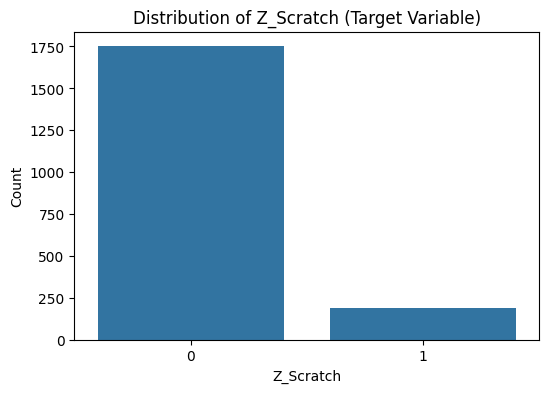

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Z_Scratch (Target Variable)')
plt.xlabel('Z_Scratch')
plt.ylabel('Count')
plt.show()

### Data Splitting

Now, let's split the dataset into training and testing sets. This is a crucial step for evaluating the performance of our machine learning model on unseen data. We'll use a test size of 20% and set a `random_state` for reproducibility.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1552, 13)
X_test shape: (389, 13)
y_train shape: (1552,)
y_test shape: (389,)


### Decision Tree Model Training and Evaluation

Now, let's train a Decision Tree Classifier on our training data (`X_train`, `y_train`) and evaluate its performance on both the training and testing sets. This will give us an idea of how well the model has learned the patterns and how it performs on unseen data.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=10,random_state=42)

# Train the model on the training data
dtc.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred = dtc.predict(X_train)

# Evaluate the model on the training set
print('--- Training Set Evaluation ---')
print(f'Accuracy: {accuracy_score(y_train, y_train_pred):.4f}')
print('Classification Report:\n', classification_report(y_train, y_train_pred))

# Make predictions on the test set
y_test_pred = dtc.predict(X_test)

# Evaluate the model on the test set
print('\n--- Test Set Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_test_pred):.4f}')
print('Classification Report:\n', classification_report(y_test, y_test_pred))

--- Training Set Evaluation ---
Accuracy: 0.9916
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1403
           1       0.97      0.95      0.96       149

    accuracy                           0.99      1552
   macro avg       0.98      0.97      0.98      1552
weighted avg       0.99      0.99      0.99      1552


--- Test Set Evaluation ---
Accuracy: 0.9023
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       348
           1       0.53      0.66      0.59        41

    accuracy                           0.90       389
   macro avg       0.74      0.79      0.77       389
weighted avg       0.91      0.90      0.91       389



### Hyperparameter Tuning with Grid Search

To find the optimal `max_depth` for our Decision Tree Classifier and potentially mitigate overfitting, we'll use Grid Search. This method systematically works through multiple combinations of parameter values, evaluating the model for each combination.

We will search for `max_depth` values ranging from 2 to 30.

In [25]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'max_depth': range(2, 31)  # Max depth from 2 to 30
}

# Initialize the Decision Tree Classifier
# Use the same random_state for reproducibility
dt = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='accuracy' can be used, but for imbalanced datasets, 'f1' or 'recall' for the positive class might be better.
# Let's start with 'accuracy' for now.
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best estimator (model) from the grid search
best_dtc = grid_search.best_estimator_

# Make predictions on the training set with the best model
y_train_pred_best = best_dtc.predict(X_train)

# Evaluate the best model on the training set
print('\n--- Training Set Evaluation (Best Model) ---')
print(f'Accuracy: {accuracy_score(y_train, y_train_pred_best):.4f}')
print('Classification Report:\n', classification_report(y_train, y_train_pred_best))

# Make predictions on the test set with the best model
y_test_pred_best = best_dtc.predict(X_test)

# Evaluate the best model on the test set
print('\n--- Test Set Evaluation (Best Model) ---')
print(f'Accuracy: {accuracy_score(y_test, y_test_pred_best):.4f}')
print('Classification Report:\n', classification_report(y_test, y_test_pred_best))

Best parameters: {'max_depth': 3}
Best cross-validation accuracy: 0.9098

--- Training Set Evaluation (Best Model) ---
Accuracy: 0.9227
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      1403
           1       0.72      0.32      0.44       149

    accuracy                           0.92      1552
   macro avg       0.83      0.65      0.70      1552
weighted avg       0.91      0.92      0.91      1552


--- Test Set Evaluation (Best Model) ---
Accuracy: 0.9203
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96       348
           1       0.71      0.41      0.52        41

    accuracy                           0.92       389
   macro avg       0.82      0.70      0.74       389
weighted avg       0.91      0.92      0.91       389



### Random Forest Model Training and Evaluation

Let's train a Random Forest Classifier, which is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. We will evaluate its performance on both the training and test sets.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier
# Using a reasonable number of estimators and a random state for reproducibility
# You might want to tune parameters like n_estimators, max_depth, etc., using GridSearchCV similar to the Decision Tree.
rfc = RandomForestClassifier(n_estimators=1, random_state=42)

# Train the model on the training data
rfc.fit(X_train, y_train)

# Make predictions on the training set
y_train_pred_rfc = rfc.predict(X_train)

# Evaluate the model on the training set
print('--- Random Forest Training Set Evaluation ---')
print(f'Accuracy: {accuracy_score(y_train, y_train_pred_rfc):.4f}')
print('Classification Report:\n', classification_report(y_train, y_train_pred_rfc))

# Make predictions on the test set
y_test_pred_rfc = rfc.predict(X_test)

# Evaluate the model on the test set
print('\n--- Random Forest Test Set Evaluation ---')
print(f'Accuracy: {accuracy_score(y_test, y_test_pred_rfc):.4f}')
print('Classification Report:\n', classification_report(y_test, y_test_pred_rfc))

--- Random Forest Training Set Evaluation ---
Accuracy: 0.9639
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1403
           1       0.83      0.78      0.81       149

    accuracy                           0.96      1552
   macro avg       0.91      0.88      0.89      1552
weighted avg       0.96      0.96      0.96      1552


--- Random Forest Test Set Evaluation ---
Accuracy: 0.8612
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       348
           1       0.34      0.34      0.34        41

    accuracy                           0.86       389
   macro avg       0.63      0.63      0.63       389
weighted avg       0.86      0.86      0.86       389



In [30]:
correlation_matrix_x = x.corr()
display(correlation_matrix_x)

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Orientation_Index,Luminosity_Index,SigmoidOfAreas
X_Minimum,1.000000,0.988314,0.041821,0.041807,-0.307322,-0.258937,-0.118757,-0.339045,0.237637,-0.075554,0.178585,-0.031578,-0.355251
X_Maximum,0.988314,1.000000,0.052147,0.052135,-0.225399,-0.186326,-0.090138,-0.247052,0.168649,-0.062392,0.115019,-0.038996,-0.286736
Y_Minimum,0.041821,0.052147,1.000000,1.000000,0.017670,0.023843,0.024150,0.007362,-0.065703,-0.067785,-0.086497,-0.090654,0.025257
Y_Maximum,0.041807,0.052135,1.000000,1.000000,0.017840,0.024038,0.024380,0.007499,-0.065733,-0.067776,-0.086480,-0.090666,0.025284
Pixels_Areas,-0.307322,-0.225399,0.017670,0.017840,1.000000,0.966644,0.827199,0.978952,-0.497204,0.110063,-0.137604,-0.043449,0.422947
X_Perimeter,-0.258937,-0.186326,0.023843,0.024038,0.966644,1.000000,0.912436,0.912956,-0.400427,0.111363,-0.101731,-0.032617,0.380605
Y_Perimeter,-0.118757,-0.090138,0.024150,0.024380,0.827199,0.912436,1.000000,0.704876,-0.213758,0.061809,0.031381,-0.047778,0.191772
Sum_of_Luminosity,-0.339045,-0.247052,0.007362,0.007499,0.978952,0.912956,0.704876,1.000000,-0.540566,0.136515,-0.158483,-0.014067,0.464248
Minimum_of_Luminosity,0.237637,0.168649,-0.065703,-0.065733,-0.497204,-0.400427,-0.213758,-0.540566,1.000000,0.429605,0.057123,0.669534,-0.514797
Maximum_of_Luminosity,-0.075554,-0.062392,-0.067785,-0.067776,0.110063,0.111363,0.061809,0.136515,0.429605,1.000000,-0.169747,0.870160,-0.039651


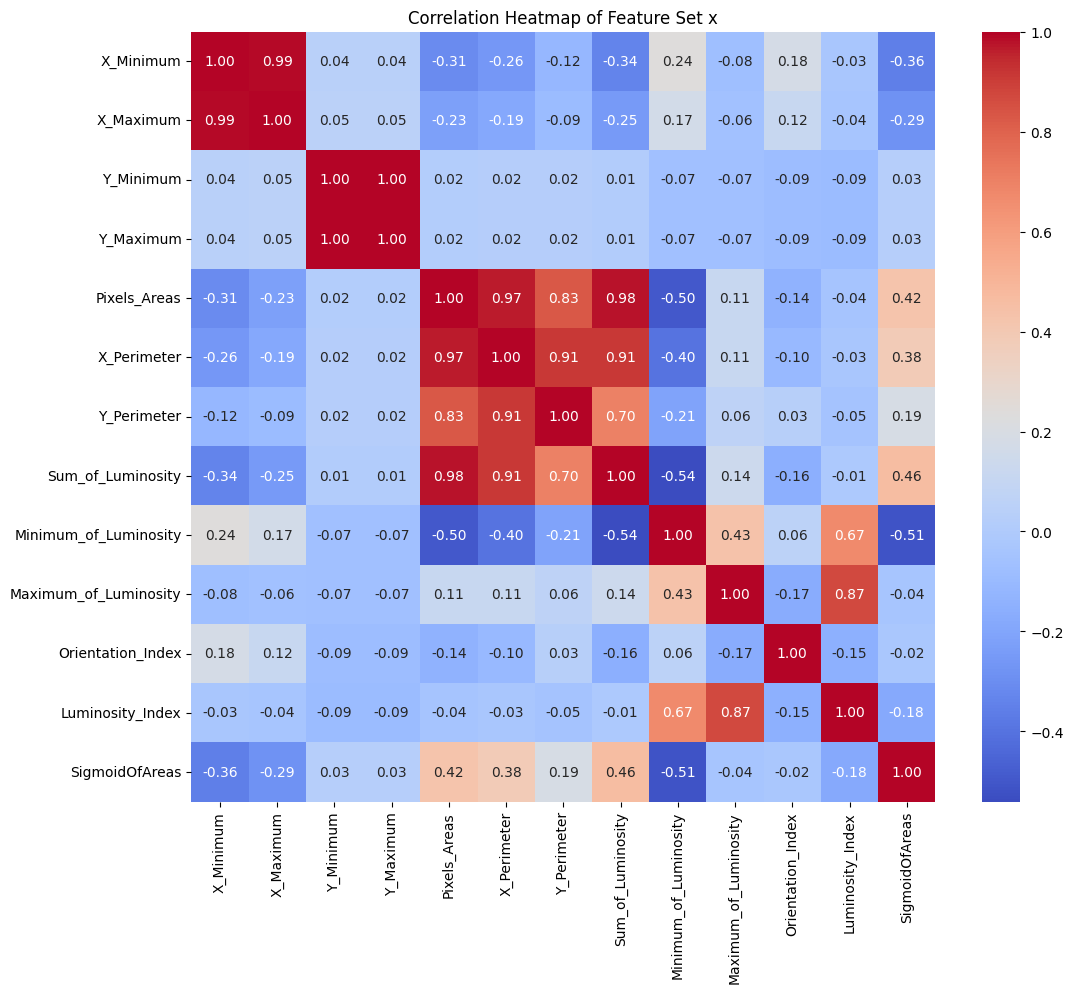

In [31]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_x, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Feature Set x')
plt.show()